In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda skill_list: ast.literal_eval(skill_list) if isinstance(skill_list, str) else skill_list
)

c:\Users\DELL\anaconda3\envs\data_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\DELL\anaconda3\envs\data_project\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub\datasets--lukebarousse--data_jobs. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to

<h4>US analysis</h4>

In [3]:
df_us = df[df['job_country'] == 'United States']

In [4]:
df_skills = df_us.explode('job_skills')
skill_count = df_skills.groupby(['job_title_short', 'job_skills']).size()
df_skill_count = skill_count.reset_index(name='skill_count')
df_skill_count = df_skill_count.sort_values(by='skill_count', ascending=False)

df_skill_count


,job_title_short,job_skills,skill_count
886,Data Scientist,python,42379
472,Data Analyst,sql,34452
921,Data Scientist,sql,30034
351,Data Analyst,excel,27519
890,Data Scientist,r,26022
...,...,...,...
1103,Machine Learning Engineer,sqlite,1
1244,Senior Data Analyst,react.js,1
1198,Senior Data Analyst,laravel,1
35,Business Analyst,dplyr,1


In [5]:
job_titles = df_skill_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

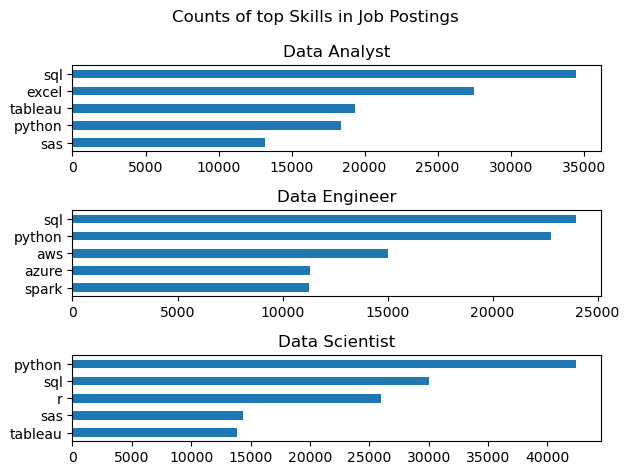

In [6]:
fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):

    df_plot = (df_skill_count[df_skill_count['job_title_short'] == job_title].head(5))
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    #ax[i].set_xlim(0, 120000)

fig.suptitle('Counts of top Skills in Job Postings')
fig.tight_layout()

In [8]:
df_job_title_count = df_us['job_title_short'].value_counts().reset_index(name='job_total')

In [13]:
df_skill_perc = pd.merge(df_skill_count, df_job_title_count, how='left', on='job_title_short')

df_skill_perc['skill_percent'] = 100 *  df_skill_perc['skill_count'] / df_skill_perc['job_total']

df_skill_perc

,job_title_short,job_skills,skill_count,job_total,skill_percent
0,Data Scientist,python,42379,58830,72.036376
1,Data Analyst,sql,34452,67816,50.802171
2,Data Scientist,sql,30034,58830,51.052184
3,Data Analyst,excel,27519,67816,40.578919
4,Data Scientist,r,26022,58830,44.232534
...,...,...,...,...,...
1865,Machine Learning Engineer,sqlite,1,921,0.108578
1866,Senior Data Analyst,react.js,1,11791,0.008481
1867,Senior Data Analyst,laravel,1,11791,0.008481
1868,Business Analyst,dplyr,1,7382,0.013546


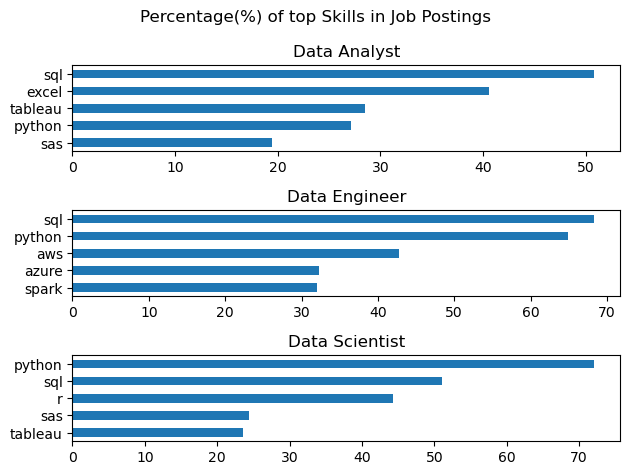

In [16]:
fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):

    df_plot = (df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(5))
    df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title=job_title)
    
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    #ax[i].set_xlim(0, 120000)

fig.suptitle('Percentage(%) of top Skills in Job Postings')
fig.tight_layout()